# 20: FD003 cluster error analysis

Objetivo: analizar si patrones latentes de degradacion en FD003 ayudan a explicar los errores del pipeline transferido desde FD001.

No se hace tuning, no se cambia el modelo, no se usa test oficial y `cluster_id` no se usa como feature. Los clusters son analisis post-hoc, no etiquetas reales de fault mode.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / 'CMAPSSData').exists() and PROJECT_ROOT.parent != PROJECT_ROOT:
    PROJECT_ROOT = PROJECT_ROOT.parent

import sys
sys.path.append(str(PROJECT_ROOT))

DATA_DIR = PROJECT_ROOT / 'CMAPSSData'
RESULTS_DIR = PROJECT_ROOT / 'results' / 'FD003'
FIGURES_DIR = PROJECT_ROOT / 'figures' / 'FD003'
NOTAS_DIR = PROJECT_ROOT / 'notas' / 'hallazgos' / 'FD003'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
NOTAS_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATES = [0, 1, 2, 3, 4]
sns.set_theme(style='whitegrid')


In [2]:
from src.fd003_cluster_utils import (
    add_rul_bins,
    build_cluster_error_interpretation,
    cluster_summary,
    find_existing_fd003_cluster_file,
    fit_fd003_unit_clusters,
    grouped_error_metrics,
    load_fd003_train,
    rerun_fd003_transfer_predictions,
)
from src.fd003_transfer_utils import load_fd001_final_quantile_config


## 1. Carga de resultados, configuracion y train FD003

In [3]:
config = load_fd001_final_quantile_config(RESULTS_DIR / 'fd003_transfer_fd001_pipeline_config.json')
validation_summary = pd.read_csv(RESULTS_DIR / 'fd003_transfer_fd001_pipeline_validation_summary.csv')
fd003_vs_fd001 = pd.read_csv(RESULTS_DIR / 'fd003_vs_fd001_transfer_comparison.csv')
train_raw = load_fd003_train(DATA_DIR)

print('Train FD003 shape:', train_raw.shape)
print('Units:', train_raw['unit'].nunique())
print('Nulls:', int(train_raw.isna().sum().sum()))
print('Config objective:', config['objective'], 'alpha:', config['alpha'])
display(validation_summary)
display(fd003_vs_fd001)


Train FD003 shape: (24720, 26)
Units: 100
Nulls: 0
Config objective: quantile alpha: 0.4


,dataset,model_name,model_family,objective,alpha,sample_weight_scheme,window_size,rul_cap,mean_mae,std_mae,...,std_cmapss_score,mean_dangerous_error_pct,std_dangerous_error_pct,mean_conservative_error_pct,std_conservative_error_pct,mean_bias_mean,std_bias_mean,worst_rmse,worst_cmapss_score,worst_dangerous_error_pct
0,FD003,candidate_03_B_quantile_a040_search_14,LightGBM,quantile,0.4,none,50,125,12.079831,0.690581,...,84.284135,5.6,2.19089,13.4,5.22494,-3.593095,2.766361,18.183572,555.049531,9.0


,dataset,model,window,cap,objective,alpha,mean_mae,mean_rmse,mean_r2,mean_cmapss_score,mean_dangerous_error_pct,mean_conservative_error_pct,mean_bias,worst_rmse,worst_cmapss_score
0,FD001,candidate_03_B_quantile_a040_search_14,50,125,quantile,0.4,11.656848,15.087995,0.871886,307.444648,5.044692,14.861018,-3.127690,16.925379,398.125028
1,FD003,candidate_03_B_quantile_a040_search_14,50,125,quantile,0.4,12.079831,16.448624,0.848610,424.430214,5.600000,13.400000,-3.593095,18.183572,555.049531


## 2. Clusters latentes de motores FD003

Si existe un archivo previo de clusters, se usa. Si no existe, se reconstruye con KMeans k=2 sobre features por motor calculadas con la trayectoria completa de train FD003. Esto es post-hoc para estudiar errores; no es una variable disponible para produccion/test y no se usa como input del modelo.

In [4]:
cluster_path = find_existing_fd003_cluster_file(PROJECT_ROOT)
if cluster_path is not None:
    print('Cluster file existente:', cluster_path)
    unit_clusters = pd.read_csv(cluster_path)
else:
    print('No se encontro cluster file previo. Reconstruyendo clusters con train FD003 completo.')
    unit_clusters, cluster_feature_columns = fit_fd003_unit_clusters(train_raw, n_clusters=2, random_state=42)
    unit_clusters.to_csv(RESULTS_DIR / 'fd003_unit_clusters.csv', index=False)
    cluster_path = RESULTS_DIR / 'fd003_unit_clusters.csv'

if 'total_life' not in unit_clusters.columns:
    life = train_raw.groupby('unit', as_index=False)['cycle'].max().rename(columns={'unit': 'unit_number', 'cycle': 'total_life'})
    unit_clusters = unit_clusters.merge(life, on='unit_number', how='left')

cluster_stats = cluster_summary(unit_clusters)
cluster_stats.to_csv(RESULTS_DIR / 'fd003_cluster_summary.csv', index=False)
display(unit_clusters.head())
display(cluster_stats)


No se encontro cluster file previo. Reconstruyendo clusters con train FD003 completo.


,unit_number,total_life,n_cycles,cluster_sensors,sensor_7_initial_mean,sensor_7_final_mean,sensor_7_delta_final_initial,sensor_7_mean,sensor_7_std,sensor_7_slope,...,sensor_15_final_mean,sensor_15_delta_final_initial,sensor_15_mean,sensor_15_std,sensor_15_slope,cluster_id,cluster_method,n_clusters,cluster_random_state,cluster_feature_columns
0,1,259,259,"sensor_7,sensor_9,sensor_12,sensor_14,sensor_15",554.599,551.630,-2.969,553.613166,0.911120,-0.010389,...,8.51412,0.10853,8.432769,0.036303,0.000362,1,kmeans,2,42,"sensor_7_initial_mean,sensor_7_final_mean,sens..."
1,2,253,253,"sensor_7,sensor_9,sensor_12,sensor_14,sensor_15",553.646,567.359,13.713,556.435138,3.773254,0.043905,...,8.25380,-0.12772,8.355038,0.042857,-0.000456,0,kmeans,2,42,"sensor_7_initial_mean,sensor_7_final_mean,sens..."
2,3,222,222,"sensor_7,sensor_9,sensor_12,sensor_14,sensor_15",554.646,551.680,-2.966,553.714730,0.878766,-0.011364,...,8.49769,0.10430,8.429477,0.037557,0.000460,1,kmeans,2,42,"sensor_7_initial_mean,sensor_7_final_mean,sens..."
3,4,272,272,"sensor_7,sensor_9,sensor_12,sensor_14,sensor_15",553.353,551.231,-2.122,552.760735,0.701690,-0.006730,...,8.52729,0.08042,8.466885,0.028686,0.000247,1,kmeans,2,42,"sensor_7_initial_mean,sensor_7_final_mean,sens..."
4,5,213,213,"sensor_7,sensor_9,sensor_12,sensor_14,sensor_15",553.679,551.518,-2.161,553.082958,0.706276,-0.008967,...,8.51107,0.07081,8.453891,0.030822,0.000347,1,kmeans,2,42,"sensor_7_initial_mean,sensor_7_final_mean,sens..."


,cluster_id,n_units,mean_total_life,median_total_life,min_total_life,max_total_life
0,0,44,304.659091,286.5,190,525
1,1,56,202.053571,193.0,145,341


## 3. Predicciones granulares por corte

In [5]:
predictions_path = RESULTS_DIR / 'fd003_transfer_fd001_pipeline_validation_predictions.csv'
if predictions_path.exists():
    granular_predictions = pd.read_csv(predictions_path)
    print('Cargando predicciones granulares existentes:', predictions_path)
else:
    print('No hay predicciones granulares. Recorriendo validacion multi-split con la misma configuracion del notebook 19.')
    detail, granular_predictions = rerun_fd003_transfer_predictions(
        config=config,
        data_dir=DATA_DIR,
        dropped_columns=config['fd003_dropped_zero_variance_columns'],
        random_states=RANDOM_STATES,
        results_dir=RESULTS_DIR,
    )
    detail.to_csv(RESULTS_DIR / 'fd003_transfer_fd001_pipeline_validation_detail.csv', index=False)

granular_predictions = granular_predictions.drop(columns=['cluster_id'], errors='ignore')
granular_predictions = granular_predictions.merge(
    unit_clusters[['unit_number', 'cluster_id']],
    on='unit_number',
    how='left',
)
granular_predictions.to_csv(predictions_path, index=False)
display(granular_predictions.head())
print('Predicciones:', granular_predictions.shape)


No hay predicciones granulares. Recorriendo validacion multi-split con la misma configuracion del notebook 19.


,random_state,unit_number,cutoff_cycle,true_rul,pred_rul,error,abs_error,squared_error,dangerous_error,conservative_error,cmapss_penalty,cluster_id
0,0,3,82,140.0,118.757240,-21.242760,21.242760,451.254848,False,True,4.124631,1
1,0,3,112,110.0,113.091592,3.091592,3.091592,9.557942,False,False,0.362279,1
2,0,3,142,80.0,100.392258,20.392258,20.392258,415.844176,True,False,6.684657,1
3,0,3,172,50.0,51.063148,1.063148,1.063148,1.130284,False,False,0.112172,1
4,0,3,202,20.0,20.345415,0.345415,0.345415,0.119312,False,False,0.035145,1


Predicciones: (500, 12)


## 4. Metricas por cluster

In [6]:
metrics_by_cluster = grouped_error_metrics(granular_predictions, ['cluster_id'])
metrics_by_cluster.to_csv(RESULTS_DIR / 'fd003_transfer_fd001_pipeline_metrics_by_cluster.csv', index=False)
display(metrics_by_cluster)


,cluster_id,n_predictions,n_units,mae,rmse,r2,cmapss_score,cmapss_score_mean,dangerous_error_pct,conservative_error_pct,bias_mean,median_error,abs_error_p90,abs_error_p95
0,0,230,32,12.169247,16.371225,0.851102,921.264869,4.005499,4.782609,13.043478,-4.424619,-2.362378,28.195624,34.531348
1,1,270,39,12.003662,16.622914,0.846488,1200.886201,4.447727,6.296296,13.703704,-2.884759,0.213454,29.431966,35.321594


## 5. Metricas por cluster y rango de RUL

In [7]:
predictions_with_bins = add_rul_bins(granular_predictions)
metrics_by_cluster_bin = grouped_error_metrics(predictions_with_bins, ['cluster_id', 'rul_bin'])
metrics_by_cluster_bin.to_csv(RESULTS_DIR / 'fd003_transfer_fd001_pipeline_metrics_by_cluster_and_rul_bin.csv', index=False)
display(metrics_by_cluster_bin)


,cluster_id,rul_bin,n_predictions,n_units,mae,rmse,r2,cmapss_score,cmapss_score_mean,dangerous_error_pct,conservative_error_pct,bias_mean,median_error,abs_error_p90,abs_error_p95
0,0,0-30,46,32,3.176318,4.158194,NaN,17.750045,0.385871,0.000000,0.000000,-0.021519,-0.868895,5.978348,7.059095
1,0,101+,92,32,18.852600,22.027776,-1.156546,555.666289,6.039851,0.000000,32.608696,-14.388145,-16.314840,34.717603,42.150559
2,0,31-60,46,32,8.140961,11.109844,NaN,152.282359,3.310486,4.347826,0.000000,1.645812,0.692796,15.313739,18.663349
3,0,61-100,46,32,11.823757,15.130105,NaN,195.566175,4.251439,19.565217,0.000000,5.028900,2.057219,23.613337,31.182012
4,1,0-30,54,39,3.287095,4.440247,NaN,22.372256,0.414301,0.000000,0.000000,0.722673,0.581316,7.184418,9.791679
5,1,101+,108,39,17.239595,21.547461,-1.063525,715.066280,6.620984,0.000000,31.481481,-13.441715,-14.921698,35.846553,42.849450
6,1,31-60,54,39,7.843157,10.865994,NaN,118.004995,2.185278,9.259259,0.000000,4.794467,3.015253,18.855294,23.575885
7,1,61-100,54,39,14.408866,17.754848,NaN,345.442669,6.397086,22.222222,5.555556,6.942496,7.352541,29.124316,31.448185


## 6. Graficos

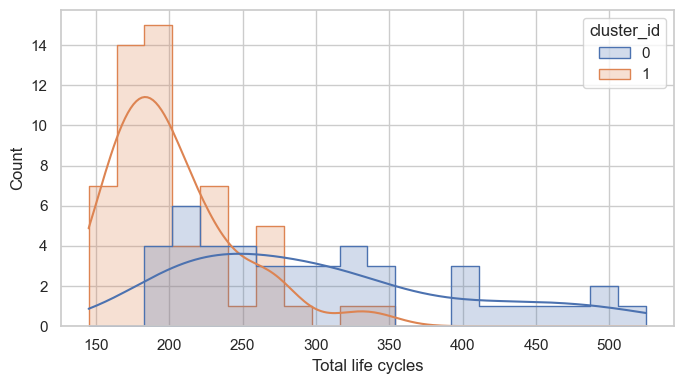

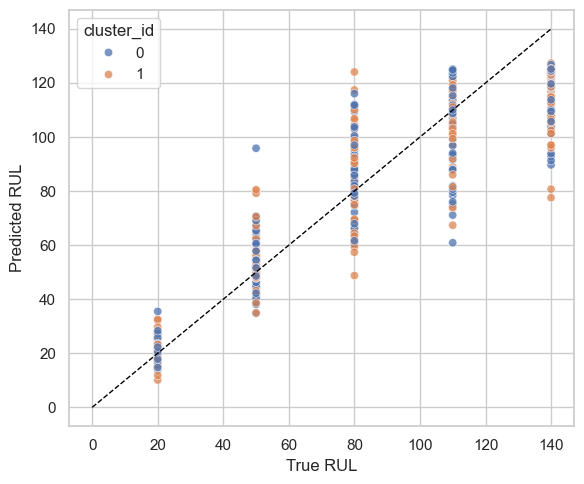

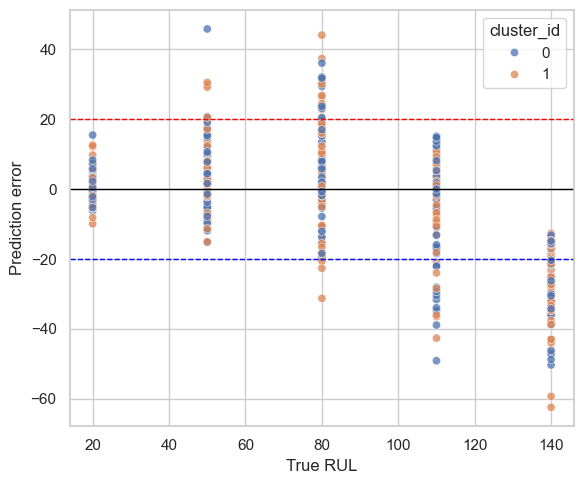

In [8]:
plt.figure(figsize=(7, 4))
sns.histplot(data=unit_clusters, x='total_life', hue='cluster_id', bins=20, kde=True, element='step')
plt.xlabel('Total life cycles')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fd003_clusters_life_distribution.png', dpi=150)
plt.show()
plt.close()

plt.figure(figsize=(6, 5))
sns.scatterplot(data=granular_predictions, x='true_rul', y='pred_rul', hue='cluster_id', alpha=0.75)
max_axis = max(granular_predictions['true_rul'].max(), granular_predictions['pred_rul'].max())
plt.plot([0, max_axis], [0, max_axis], color='black', linestyle='--', linewidth=1)
plt.xlabel('True RUL')
plt.ylabel('Predicted RUL')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fd003_pred_vs_true_by_cluster.png', dpi=150)
plt.show()
plt.close()

plt.figure(figsize=(6, 5))
sns.scatterplot(data=granular_predictions, x='true_rul', y='error', hue='cluster_id', alpha=0.75)
plt.axhline(0, color='black', linestyle='-', linewidth=1)
plt.axhline(20, color='red', linestyle='--', linewidth=1)
plt.axhline(-20, color='blue', linestyle='--', linewidth=1)
plt.xlabel('True RUL')
plt.ylabel('Prediction error')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fd003_error_vs_true_rul_by_cluster.png', dpi=150)
plt.show()
plt.close()


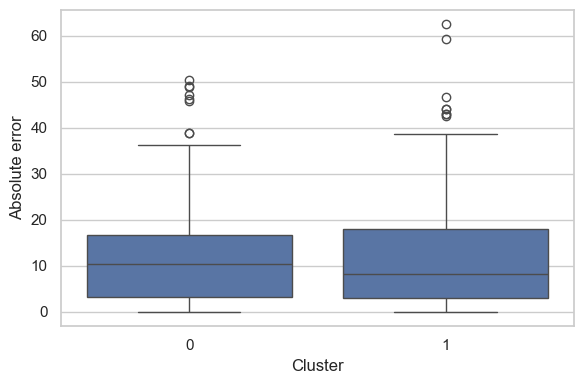

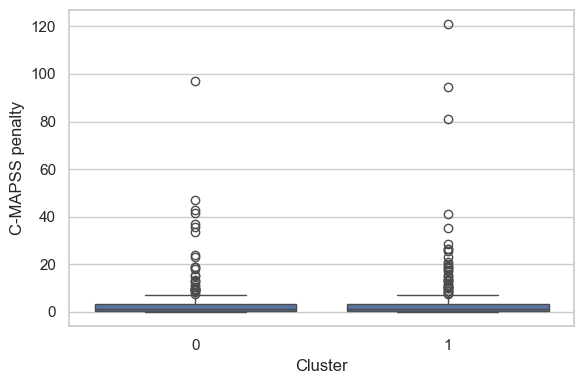

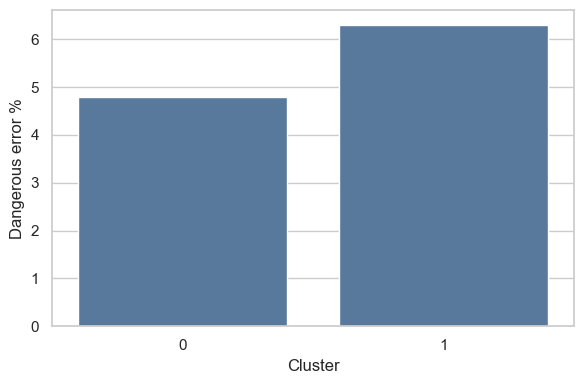

,cluster_id,n_predictions,n_units,mae,rmse,r2,cmapss_score,cmapss_score_mean,dangerous_error_pct,conservative_error_pct,bias_mean,median_error,abs_error_p90,abs_error_p95
0,0,230,32,12.169247,16.371225,0.851102,921.264869,4.005499,4.782609,13.043478,-4.424619,-2.362378,28.195624,34.531348
1,1,270,39,12.003662,16.622914,0.846488,1200.886201,4.447727,6.296296,13.703704,-2.884759,0.213454,29.431966,35.321594


In [9]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=granular_predictions, x='cluster_id', y='abs_error')
plt.xlabel('Cluster')
plt.ylabel('Absolute error')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fd003_abs_error_by_cluster.png', dpi=150)
plt.show()
plt.close()

plt.figure(figsize=(6, 4))
sns.boxplot(data=granular_predictions, x='cluster_id', y='cmapss_penalty')
plt.xlabel('Cluster')
plt.ylabel('C-MAPSS penalty')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fd003_cmapss_penalty_by_cluster.png', dpi=150)
plt.show()
plt.close()

plt.figure(figsize=(6, 4))
sns.barplot(data=metrics_by_cluster, x='cluster_id', y='dangerous_error_pct', color='#4C78A8')
plt.xlabel('Cluster')
plt.ylabel('Dangerous error %')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fd003_dangerous_error_rate_by_cluster.png', dpi=150)
plt.show()
plt.close()

display(metrics_by_cluster)


## 7. Interpretacion guardada

In [10]:
interpretation = build_cluster_error_interpretation(cluster_stats, metrics_by_cluster, metrics_by_cluster_bin)
interpretation_path = NOTAS_DIR / 'fd003_cluster_error_analysis_interpretation.txt'
interpretation_path.write_text(interpretation, encoding='utf-8')
print(interpretation_path)
print(interpretation)


C:\Users\lauta\OneDrive\Escritorio\ML\TPF-ML\results\FD003\fd003_cluster_error_analysis_interpretation.txt
FD003 - Analisis de errores por clusters latentes

Advertencia metodologica:
Los clusters no son etiquetas reales de fault mode. Se interpretan como patrones latentes de degradacion y se usan solo para analisis de error.
No se usaron como feature del modelo, no se uso test oficial y no se selecciono modelo con esta informacion.

Resumen de clusters:
- Cluster 0: 44 motores, vida media 304.66, mediana 286.50, min 190, max 525.
- Cluster 1: 56 motores, vida media 202.05, mediana 193.00, min 145, max 341.

Metricas por cluster:
- Cluster 0: MAE 12.169, RMSE 16.371, C-MAPSS 921.265, dangerous 4.78%, conservative 13.04%, bias -4.425.
- Cluster 1: MAE 12.004, RMSE 16.623, C-MAPSS 1200.886, dangerous 6.30%, conservative 13.70%, bias -2.885.

Mayor RMSE: cluster 1 (16.623).
Mayor C-MAPSS total: cluster 1 (1200.886).
Mayor dangerous error %: cluster 1 (6.30%).
Cerca de la falla (RUL 0-30),

## Cierre

Este notebook analiza si los errores del pipeline transferido desde FD001 se distribuyen de manera uniforme o si se asocian a patrones latentes de degradacion. Los clusters son post-hoc: no son etiquetas reales de fault mode y no se usan para entrenar ni seleccionar modelos.